In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# data = pd.read_csv("students.csv")
data = pd.read_csv("students.csv")

#1 understanding the data

#(A) checking the head of the data
data.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [34]:
#(B) To check for the tail of the data
data.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [35]:
#(C) To check for the shape of the data
data.shape # The output giving us the number of rows to 1000 and the number of columns to be 8

(1000, 8)

### Explanation on the above code

`The output above after checking the shape of the data shows that we have a 1000 rows and 8 columns.`

In [36]:
#(D) To check for the description of the data
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


`The reason why the result displayed by the describe function only shows the whole description for math score, reading score and writing score out of the total eight(8) columns is because they are the only ones with the Int or Number data type unlike the other columns that are of the strings data type.`

In [37]:
#(E) To check for the columns of the data
data.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
#(F) To check for the unique values in the data
data.nunique() # The nunique means the 'number of the unique values present'

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [49]:
#(F) To check for the unique values for a column separately in the data
data['gender'].unique()

array(['female', 'male'], dtype=object)

In [40]:
#2 Cleaning the data

#(A) Checking for null or missing values in the data
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [41]:
#(B) Removing and dropping some columns in the data that I don't need for the evaluation I want to carry out
student = data.drop(['race/ethnicity', 'parental level of education', 'gender', 'lunch', 'test preparation course'], axis=1)

student.head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In the above code, while indicating the specified columns you want to drop, be conscious to add axis equals 1 otherwise the code will output an error.

<Axes: >

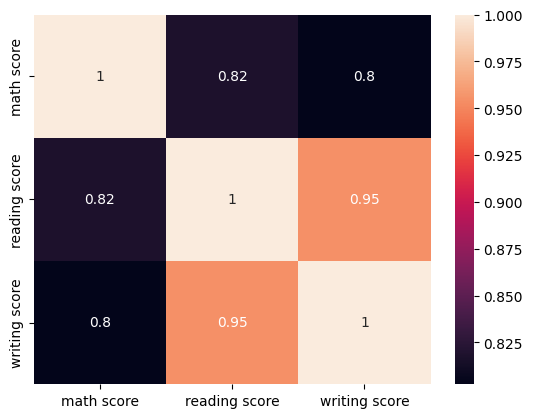

In [42]:
#3 Relationship analysis

#(A) Correlation matrix
corelation = student.corr()

sns.heatmap(corelation, xticklabels=corelation.columns, yticklabels=corelation.columns, annot=True)

Correlation matrix gives a wider perspective on what we are dealing in here by giving a robust relationship between the variables. Correlation matrix is table showing correlation coefficient between variables. It is used to summarize data and also as a diagnostic for more advanced analysis.

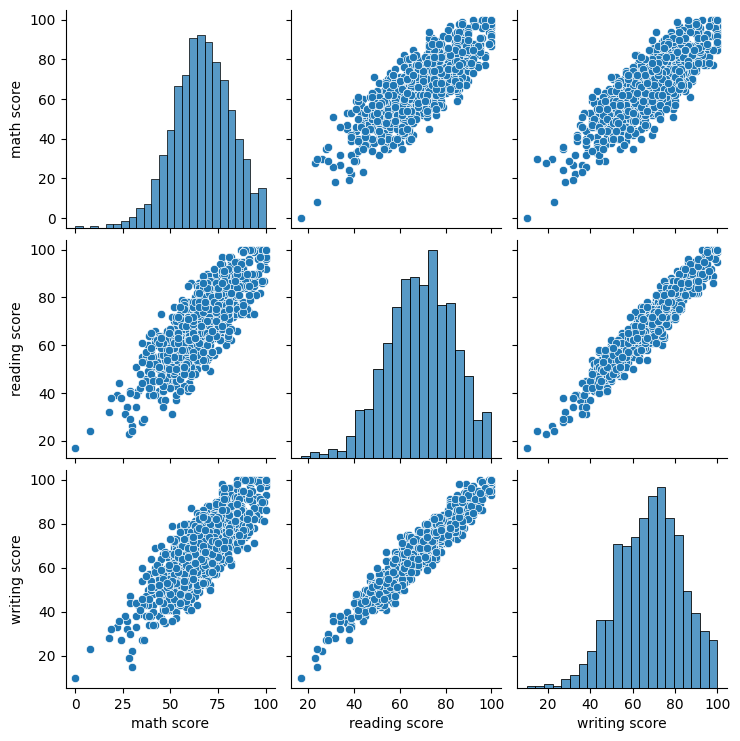

In [43]:
# Other visualizations to be carried out

#(A) Using pairplot
sns.pairplot(student)

Pairplot is good when you want to visualize the relationship between two variables. The variables can be continuous, categorical or boolean as well.

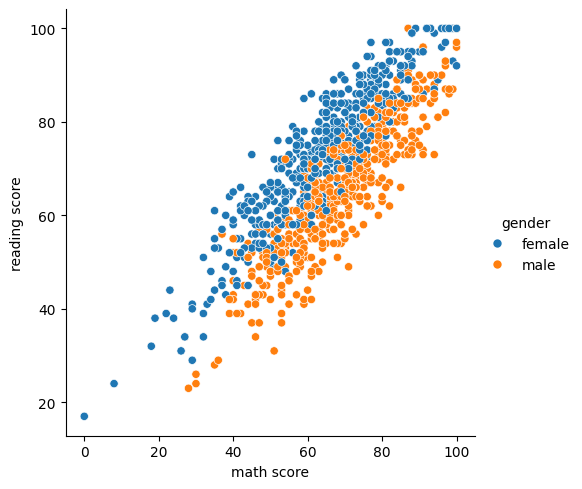

In [44]:
# Using Scatter plot
my_student = data.drop(['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'], axis=1)

sns.relplot(x= 'math score', y='reading score', hue= 'gender', data=my_student)

Scatter plot is a type of data visualization that shows the relationship between two numerical variables.

<Axes: xlabel='math score', ylabel='Count'>

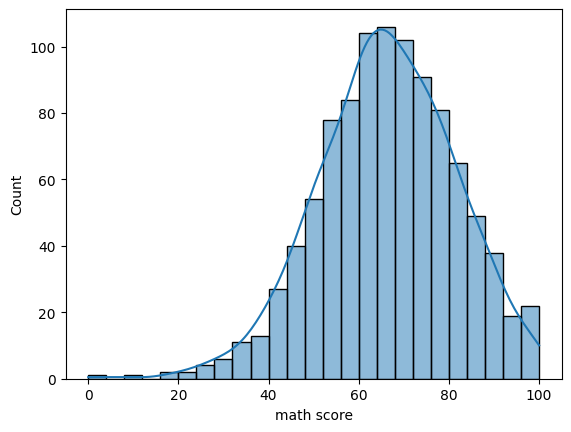

In [45]:
# Using Histogram
sns.histplot(my_student['math score'], kde=True)


An Histogram is a graphical display of data using bars of different heights. 
1. sns.histplot:
Purpose: Primarily used to create histograms. A histogram is a bar plot that represents the distribution of a dataset.

KDE Option: The kde=True argument overlays a Kernel Density Estimate (KDE) curve on top of the histogram to show a smoothed representation of the data distribution.

Bars: The primary visual element is the histogram bars.
Combination: Combines histogram and KDE curve if kde=True.

The output it displays:
(a) Displays histogram bars.
(b) Adds a KDE curve to the plot.

NOTE => You can also set the number of bins to anyone you want depending on the number of the rectangular bars you want to be visualize in the histogram chart. e.g bins = 5

<Axes: xlabel='math score', ylabel='Density'>

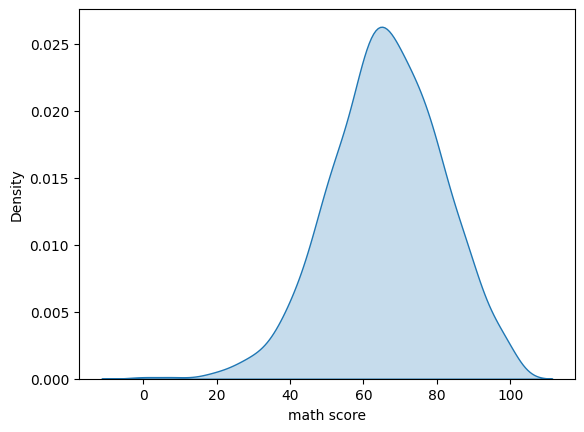

In [46]:
# Using Histogram
sns.kdeplot(my_student['math score'], fill=True)


2. sns.kdeplot:
Purpose: Specifically designed to create Kernel Density Estimate plots. KDE is a smoothed, continuous representation of the data distribution.

No Bars: It does not display bars like a histogram; it focuses solely on the smooth curve.

fill Option: The fill=True argument fills the area under the KDE curve for better visualization.

Flexibility: Focused on KDE with additional customization options for the curve.

The output it displays
(a) Displays only the smoothed KDE curve.
(b) The area under the curve is filled for visual emphasis.

When to Use Which?
(A) Use sns.histplot when you want to visualize the counts (histogram) alongside the density distribution (KDE).

(B) Use sns.kdeplot when you are primarily interested in the smoothed density curve and don't need the histogram bars.

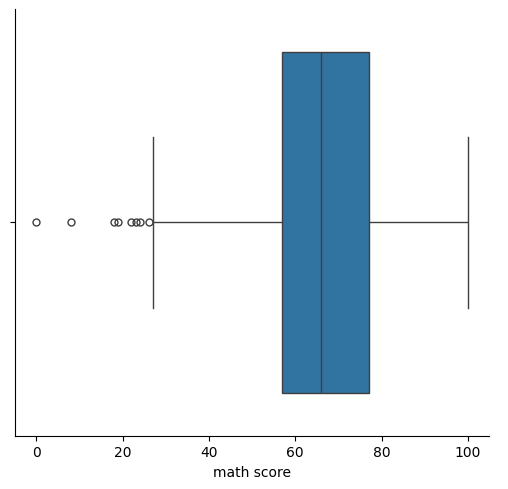

In [47]:
#Categorical plot
sns.catplot(x = 'math score', kind = 'box', data = my_student)